In [1]:
import Pkg

function find_project_directory(start_dir)
    directory = start_dir

    while true
        project_file = joinpath(directory, "Project.toml")

        if isfile(project_file) &&
           occursin("name = \"LongitudinalTomography\"", read(project_file, String))
            return directory
        end

        parent = dirname(directory)
        parent == directory && error("Could not find LongitudinalTomography Project.toml")
        directory = parent
    end
end

project_directory = find_project_directory(@__DIR__)
Pkg.activate(project_directory)

using LongitudinalTomography
using CairoMakie
using Statistics
using Random
using Zygote
using Printf

  Activating project at `~/Desktop/longitudinal_dynamics`


In [2]:
const PROTON_MASS_EV = 938.2720813e6
const TOTAL_ENERGY_EV = 8.0e9 + PROTON_MASS_EV
const GAMMA_S = TOTAL_ENERGY_EV / PROTON_MASS_EV
const BETA_S = sqrt(1 - 1 / GAMMA_S^2)

rf1 = SingleRFMachine(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-8.8e-3,
    beta_s=BETA_S,
    E_s_eV=TOTAL_ENERGY_EV,
    rf_kick_eV=60e3,
)

two_rf = NonInteractingTwoRFMachine(
    rf1;
    f_slip_hz=84 * 15.0,
    relative_phase0=0.0,
)

@printf("nu_s1                 = %.6f\n", synchrotron_tune(two_rf.rf1))
@printf("nu_slip               = %.6f\n", slip_tune(two_rf))
@printf("alpha_s               = %.3f\n", slip_stacking_parameter(two_rf))
@printf("slip period           = %.3f turns\n", 1 / abs(slip_tune(two_rf)))
@printf("fractional separation = %.6e\n", fractional_momentum_separation(two_rf))
@printf("energy separation     = %.3f MeV\n", energy_separation_eV(two_rf) * 1e-6)

nu_s1                 = 0.002364
nu_slip               = 0.014031
alpha_s               = 5.935
slip period           = 71.270 turns
fractional separation = -2.711654e-03
energy separation     = -23.970 MeV


In [3]:
grid = separatrix_grid(
    n_theta=100,
    n_P=100,
    energy_margin=0.04,
)

bucket_specs = [
    BucketSpec(:rf1, 0, 0.45),
    BucketSpec(:rf2, -1, 0.55),
]

turns = collect(0.0:1.0:250.0)

251-element Vector{Float64}:
   0.0
   1.0
   2.0
   3.0
   4.0
   5.0
   6.0
   7.0
   8.0
   9.0
  10.0
  11.0
  12.0
   ⋮
 239.0
 240.0
 241.0
 242.0
 243.0
 244.0
 245.0
 246.0
 247.0
 248.0
 249.0
 250.0

In [4]:
function phase_window_for_specs(rf1_grid, rf2_grid, bucket_specs, turns, machine; pad_buckets=0.35)
    theta_min = Inf
    theta_max = -Inf

    for spec in bucket_specs
        grid_for_spec = spec.family == :rf1 ? rf1_grid : rf2_grid
        local_min = minimum(grid_for_spec.theta_nodes)
        local_max = maximum(grid_for_spec.theta_nodes)

        centers = if spec.family == :rf1
            fill(2pi * spec.bucket_index, length(turns))
        else
            2pi * spec.bucket_index .+
                rf2_center_phase(turns, machine; N0=first(turns))
        end

        theta_min = min(theta_min, minimum(centers) + local_min)
        theta_max = max(theta_max, maximum(centers) + local_max)
    end

    pad = pad_buckets * 2pi
    return theta_min - pad, theta_max + pad
end

theta_min, theta_max = phase_window_for_specs(
    grid,
    grid,
    bucket_specs,
    turns,
    two_rf,
)


(-11.278317626387357, 20.7520736463441)

In [5]:
n_time_bins = 360
theta_bin_centers = collect(range(theta_min, theta_max; length=n_time_bins))
time_bin_centers_s = delta_t_from_theta(theta_bin_centers, rf1)
sigma_s = 0.7 * (time_bin_centers_s[2] - time_bin_centers_s[1])

response = build_slip_stacked_response(
    grid,
    bucket_specs,
    turns,
    two_rf,
    time_bin_centers_s;
    sigma=sigma_s,
)

@show size(response.matrix)
@show length(response.column_metadata)

response_tensor = reshape(
    response.matrix,
    length(response.turns),
    length(response.time_bin_centers_s),
    size(response.matrix, 2),
)

column_charge_by_turn = dropdims(sum(response_tensor; dims=2); dims=2)

@printf(
    "Response-column charge error: %.3e\n",
    maximum(abs.(column_charge_by_turn .- 1)),
)

size(response.matrix) = (90360, 12208)
length(response.column_metadata) = 12208
Response-column charge error: 7.772e-16


In [6]:
function gaussian_grid_weights(grid; theta0, P0, sigma_theta, sigma_P, charge)
    raw = exp.(
        -0.5 .* (
            ((grid.theta_nodes .- theta0) ./ sigma_theta).^2 .+
            ((grid.P_nodes .- P0) ./ sigma_P).^2
        )
    )

    return charge .* raw ./ sum(raw)
end

true_rf1_weights = gaussian_grid_weights(
    grid;
    theta0=-0.45,
    P0=0.25,
    sigma_theta=0.42,
    sigma_P=0.32,
    charge=bucket_specs[1].charge_fraction,
)

true_rf2_weights = gaussian_grid_weights(
    grid;
    theta0=0.35,
    P0=-0.20,
    sigma_theta=0.50,
    sigma_P=0.28,
    charge=bucket_specs[2].charge_fraction,
)

true_weights = vcat(true_rf1_weights, true_rf2_weights)

matrix_profiles = profiles_from_response(
    response,
    true_weights;
    normalize=false,
)

direct_profiles = direct_slip_stacked_profiles(
    response,
    true_weights,
    two_rf;
    normalize=false,
)

@printf(
    "Matrix vs direct max abs error: %.3e\n",
    maximum(abs.(matrix_profiles .- direct_profiles)),
)

@printf(
    "Total charge per turn: min %.6f, max %.6f\n",
    minimum(vec(sum(matrix_profiles; dims=2))),
    maximum(vec(sum(matrix_profiles; dims=2))),
)

Matrix vs direct max abs error: 2.776e-17
Total charge per turn: min 1.000000, max 1.000000


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


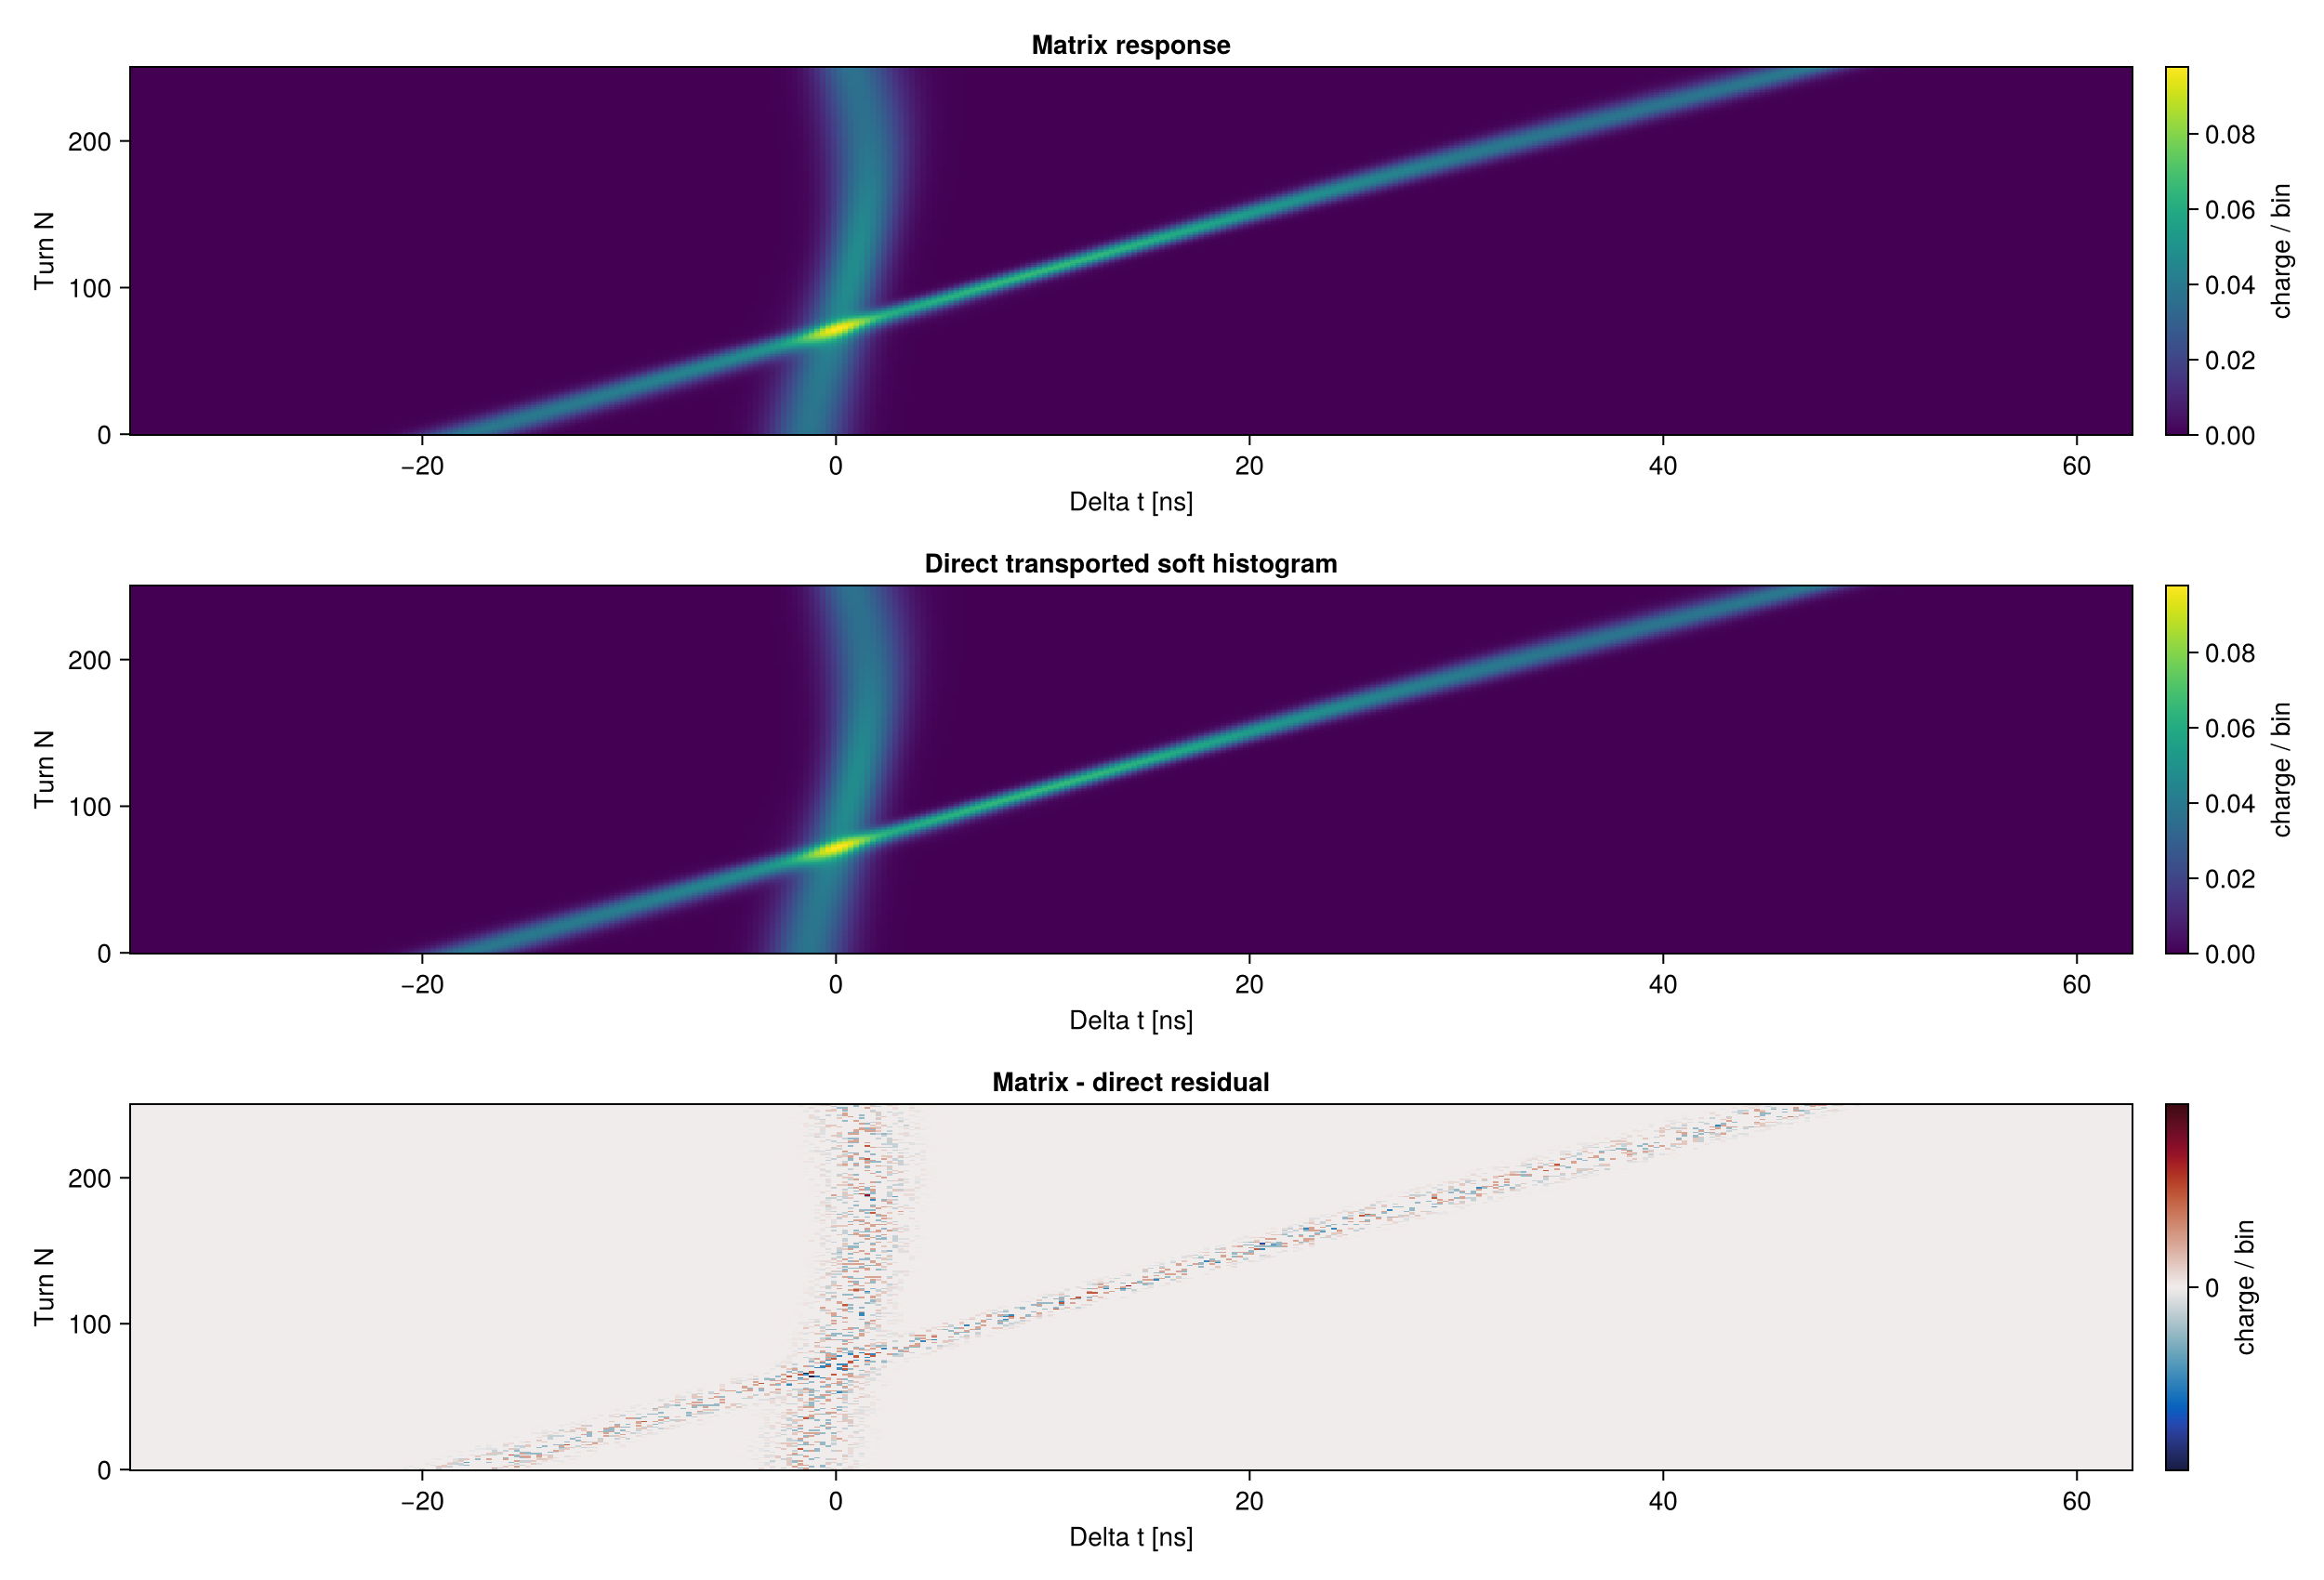

CairoMakie.Screen{IMAGE}


In [7]:
figure_forward = Figure(size=(1250, 850))

axis_matrix = Axis(
    figure_forward[1, 1];
    xlabel="Delta t [ns]",
    ylabel="Turn N",
    title="Matrix response",
)

matrix_heatmap = heatmap!(
    axis_matrix,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(matrix_profiles);
    colormap=:viridis,
)

Colorbar(figure_forward[1, 2], matrix_heatmap; label="charge / bin")

axis_direct = Axis(
    figure_forward[2, 1];
    xlabel="Delta t [ns]",
    ylabel="Turn N",
    title="Direct transported soft histogram",
)

direct_heatmap = heatmap!(
    axis_direct,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(direct_profiles);
    colormap=:viridis,
    colorrange=(0, maximum(matrix_profiles)),
)

Colorbar(figure_forward[2, 2], direct_heatmap; label="charge / bin")

residual = matrix_profiles .- direct_profiles
residual_limit = maximum(abs.(residual))

axis_residual = Axis(
    figure_forward[3, 1];
    xlabel="Delta t [ns]",
    ylabel="Turn N",
    title="Matrix - direct residual",
)

residual_heatmap = heatmap!(
    axis_residual,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(residual);
    colormap=:balance,
    colorrange=(-residual_limit, residual_limit),
)

Colorbar(figure_forward[3, 2], residual_heatmap; label="charge / bin")

display(figure_forward)

In [8]:
function reconstruct_slip_stacked_demo(
    response,
    target_profiles;
    iterations=350,
    learning_rate=0.08,
    lambda_tv=0.0,
)
    n_unknowns = size(response.matrix, 2)
    total_charge = mean(vec(sum(target_profiles; dims=2)))

    logits = zeros(Float64, n_unknowns)
    first_moment = zeros(Float64, n_unknowns)
    second_moment = zeros(Float64, n_unknowns)
    loss_history = Float64[]

    beta1 = 0.9
    beta2 = 0.999
    adam_epsilon = 1e-8

    objective(current_logits) = begin
        weights = total_charge .* grid_weights_from_logits(current_logits)
        prediction = profiles_from_response(
            response,
            weights;
            normalize=false,
        )

        profile_mse(prediction, target_profiles) +
            lambda_tv * slip_stacked_grid_total_variation(weights, response)
    end

    for iteration in 1:iterations
        loss_value, pullback = Zygote.pullback(objective, logits)
        gradient = only(pullback(one(loss_value)))

        push!(loss_history, Float64(loss_value))

        first_moment = beta1 .* first_moment .+ (1 - beta1) .* gradient
        second_moment = beta2 .* second_moment .+ (1 - beta2) .* gradient.^2

        corrected_first = first_moment ./ (1 - beta1^iteration)
        corrected_second = second_moment ./ (1 - beta2^iteration)

        logits = logits .-
            learning_rate .* corrected_first ./ (sqrt.(corrected_second) .+ adam_epsilon)
    end

    weights = total_charge .* grid_weights_from_logits(logits)
    profiles = profiles_from_response(response, weights; normalize=false)

    return (
        weights=weights,
        profiles=profiles,
        logits=logits,
        loss_history=loss_history,
    )
end

reconstruction = reconstruct_slip_stacked_demo(
    response,
    matrix_profiles;
    iterations=500,
    learning_rate=0.08,
    lambda_tv=0.0,
)

@printf(
    "Loss: %.6e -> %.6e\n",
    first(reconstruction.loss_history),
    last(reconstruction.loss_history),
)

@printf(
    "Recovered charge: %.6f\n",
    sum(reconstruction.weights),
)

Loss: 5.230073e-05 -> 2.117778e-07
Recovered charge: 1.000000


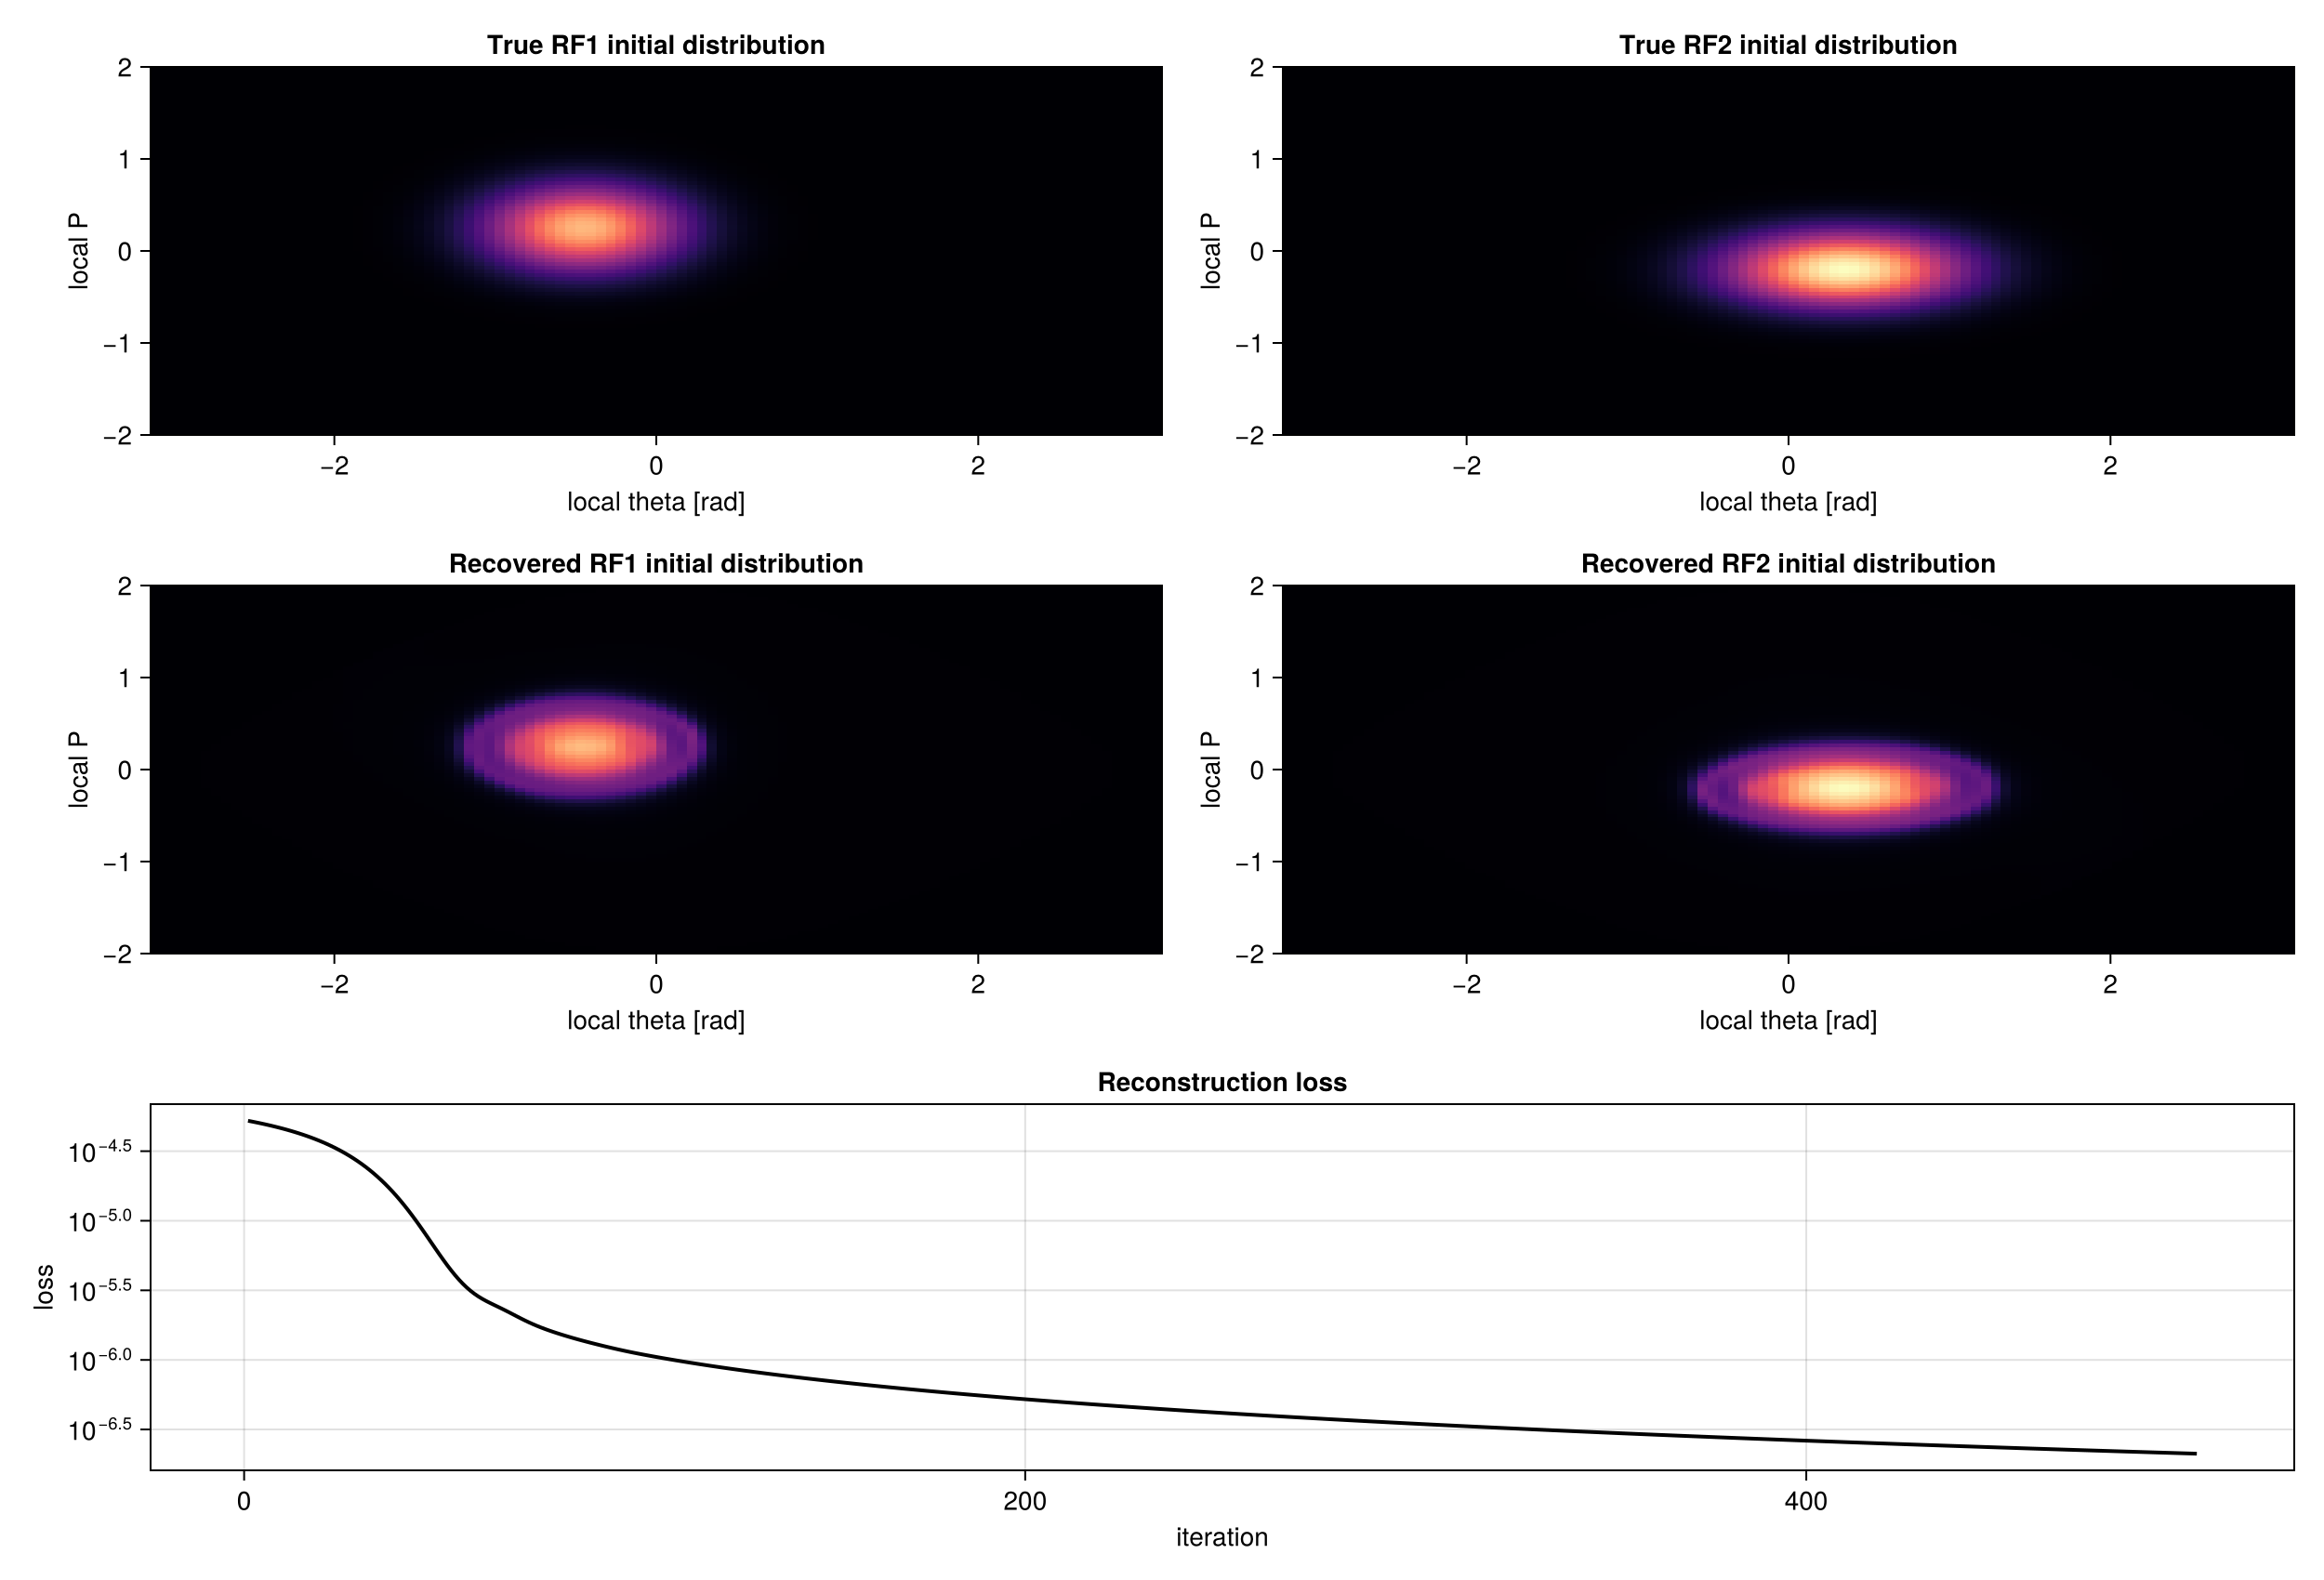

CairoMakie.Screen{IMAGE}


In [9]:

rf1_block = response.block_ranges[1]
rf2_block = response.block_ranges[2]

true_rf1_matrix = grid_weight_matrix(
    grid,
    true_weights[rf1_block];
    fill_value=0.0,
)

true_rf2_matrix = grid_weight_matrix(
    grid,
    true_weights[rf2_block];
    fill_value=0.0,
)

reco_rf1_matrix = grid_weight_matrix(
    grid,
    reconstruction.weights[rf1_block];
    fill_value=0.0,
)

reco_rf2_matrix = grid_weight_matrix(
    grid,
    reconstruction.weights[rf2_block];
    fill_value=0.0,
)

figure_reco = Figure(size=(1250, 850))

common_weight_limit = maximum([
    maximum(true_rf1_matrix),
    maximum(true_rf2_matrix),
    maximum(reco_rf1_matrix),
    maximum(reco_rf2_matrix),
])

for (plot_index, matrix, title) in [
    (1, true_rf1_matrix, "True RF1 initial distribution"),
    (2, true_rf2_matrix, "True RF2 initial distribution"),
    (3, reco_rf1_matrix, "Recovered RF1 initial distribution"),
    (4, reco_rf2_matrix, "Recovered RF2 initial distribution"),
]
    row = plot_index <= 2 ? 1 : 2
    col = plot_index <= 2 ? plot_index : plot_index - 2

    axis = Axis(
        figure_reco[row, col];
        xlabel="local theta [rad]",
        ylabel="local P",
        title=title,
    )

    heatmap!(
        axis,
        grid.theta_axis,
        grid.P_axis,
        permutedims(matrix);
        colormap=:magma,
        colorrange=(0, common_weight_limit),
    )
end

loss_axis = Axis(
    figure_reco[3, 1:2];
    xlabel="iteration",
    ylabel="loss",
    title="Reconstruction loss",
    yscale=log10,
)

lines!(
    loss_axis,
    1:length(reconstruction.loss_history),
    reconstruction.loss_history;
    color=:black,
    linewidth=2,
)

display(figure_reco)

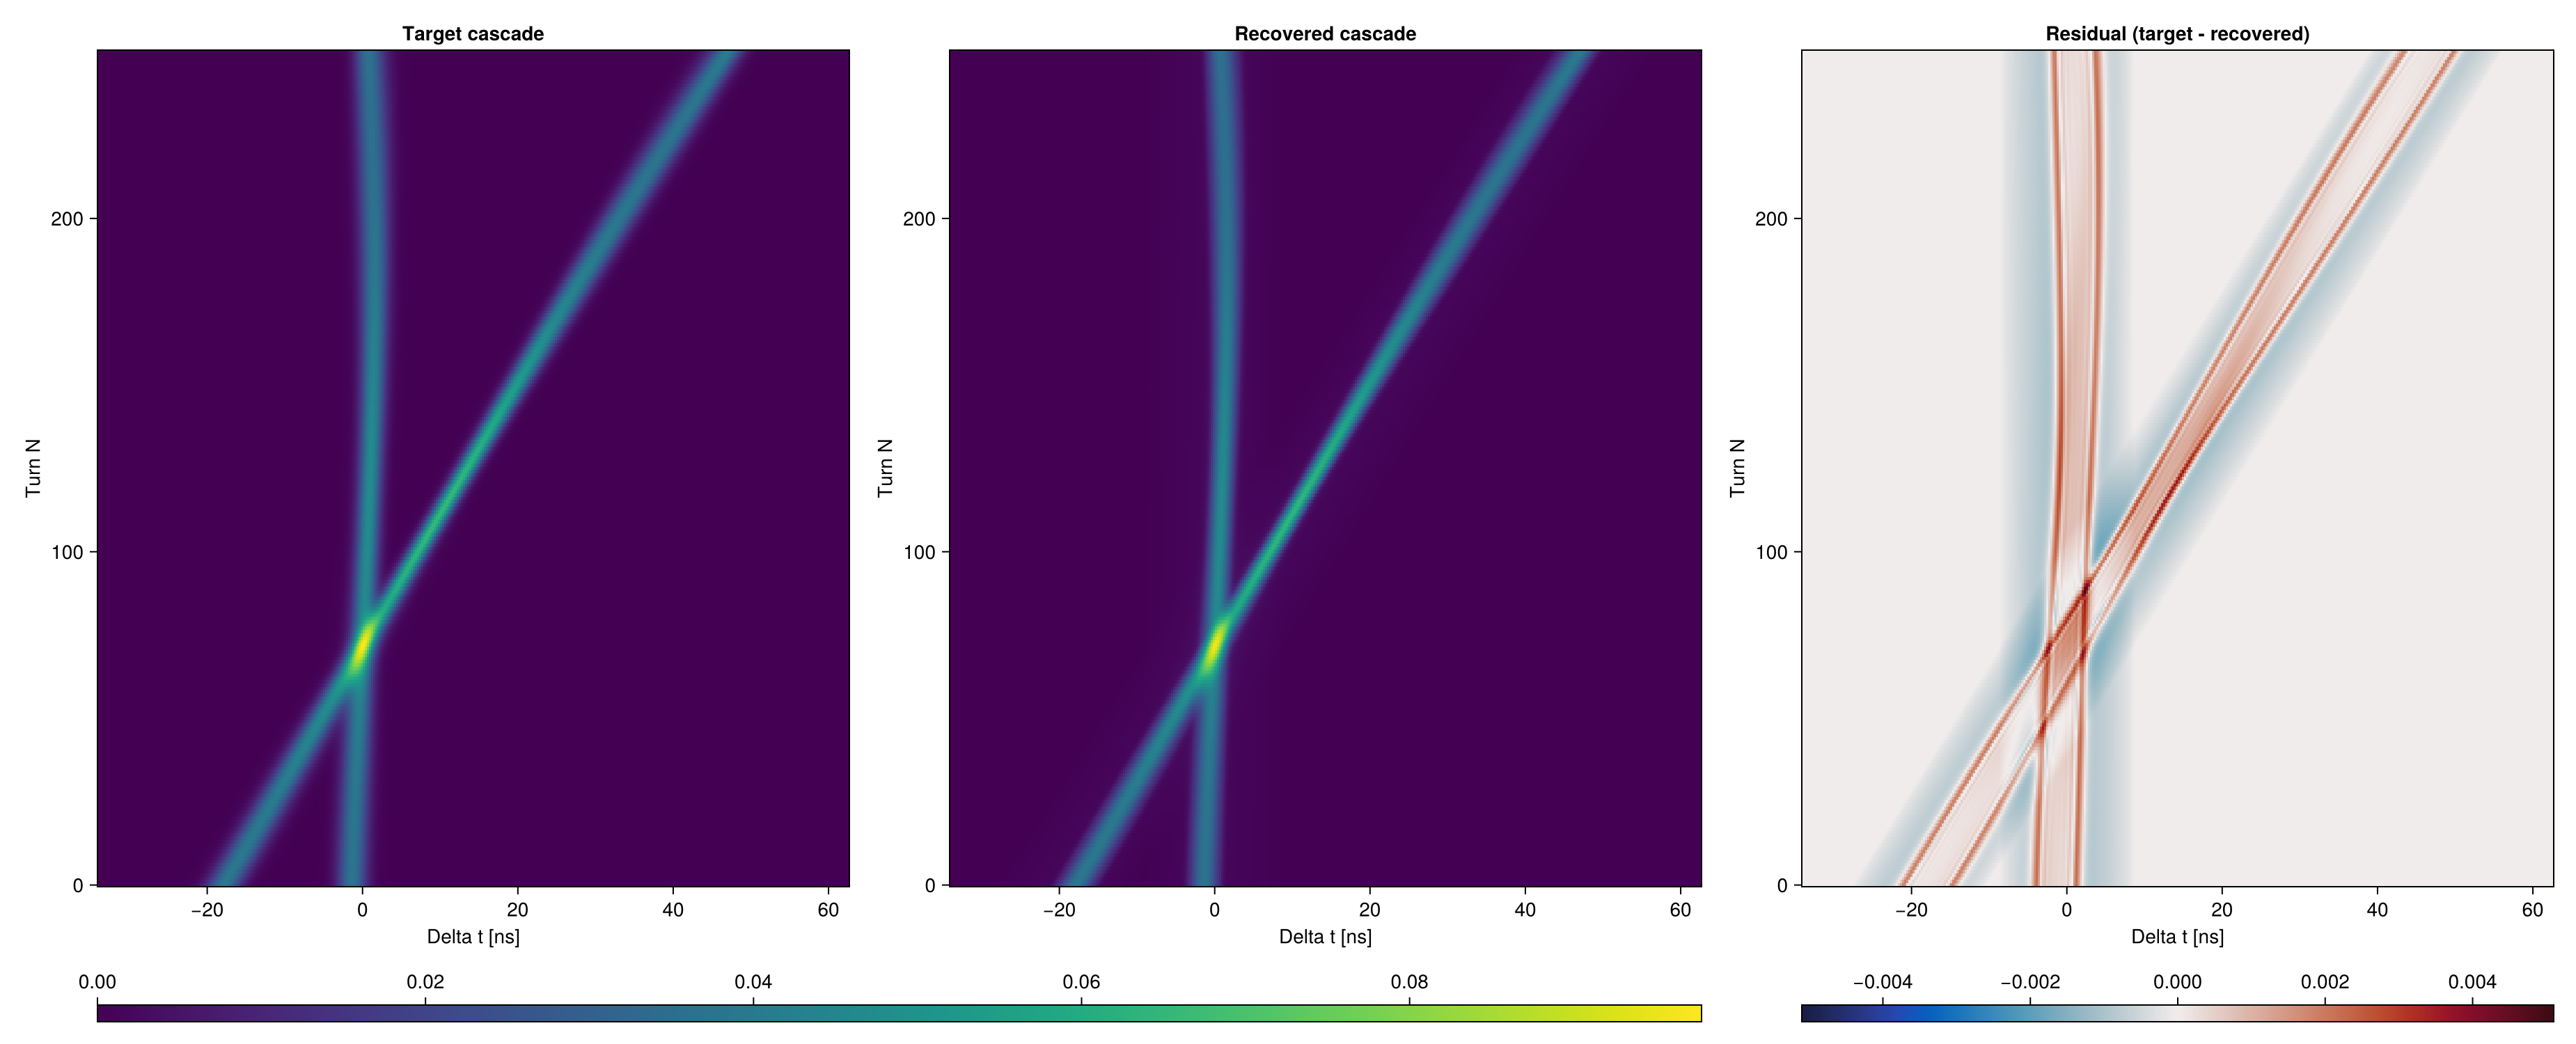

CairoMakie.Screen{IMAGE}


In [10]:
figure_profile_reco = Figure(size=(1850, 750))

target_axis = Axis(
    figure_profile_reco[1, 1];
    xlabel="Delta t [ns]",
    ylabel="Turn N",
    title="Target cascade",
)

target_hm = heatmap!(
    target_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(matrix_profiles);
    colormap=:viridis,
)

Colorbar(figure_profile_reco[2, 1:2], target_hm, vertical=false)

prediction_axis = Axis(
    figure_profile_reco[1, 2];
    xlabel="Delta t [ns]",
    ylabel="Turn N",
    title="Recovered cascade",
)

prediction_hm = heatmap!(
    prediction_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(reconstruction.profiles);
    colormap=:viridis,
    colorrange=(0, maximum(matrix_profiles)),
)

residual_axis = Axis(
    figure_profile_reco[1, 3];
    xlabel="Delta t [ns]",
    ylabel="Turn N",
    title="Residual (target - recovered)",
)

residual_hm = heatmap!(
    residual_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(matrix_profiles .- reconstruction.profiles);
    colormap=:balance,
    colorrange=(-maximum(abs.(matrix_profiles .- reconstruction.profiles)), maximum(abs.(matrix_profiles .- reconstruction.profiles))),
)

Colorbar(figure_profile_reco[2, 3], residual_hm, vertical=false)

display(figure_profile_reco)

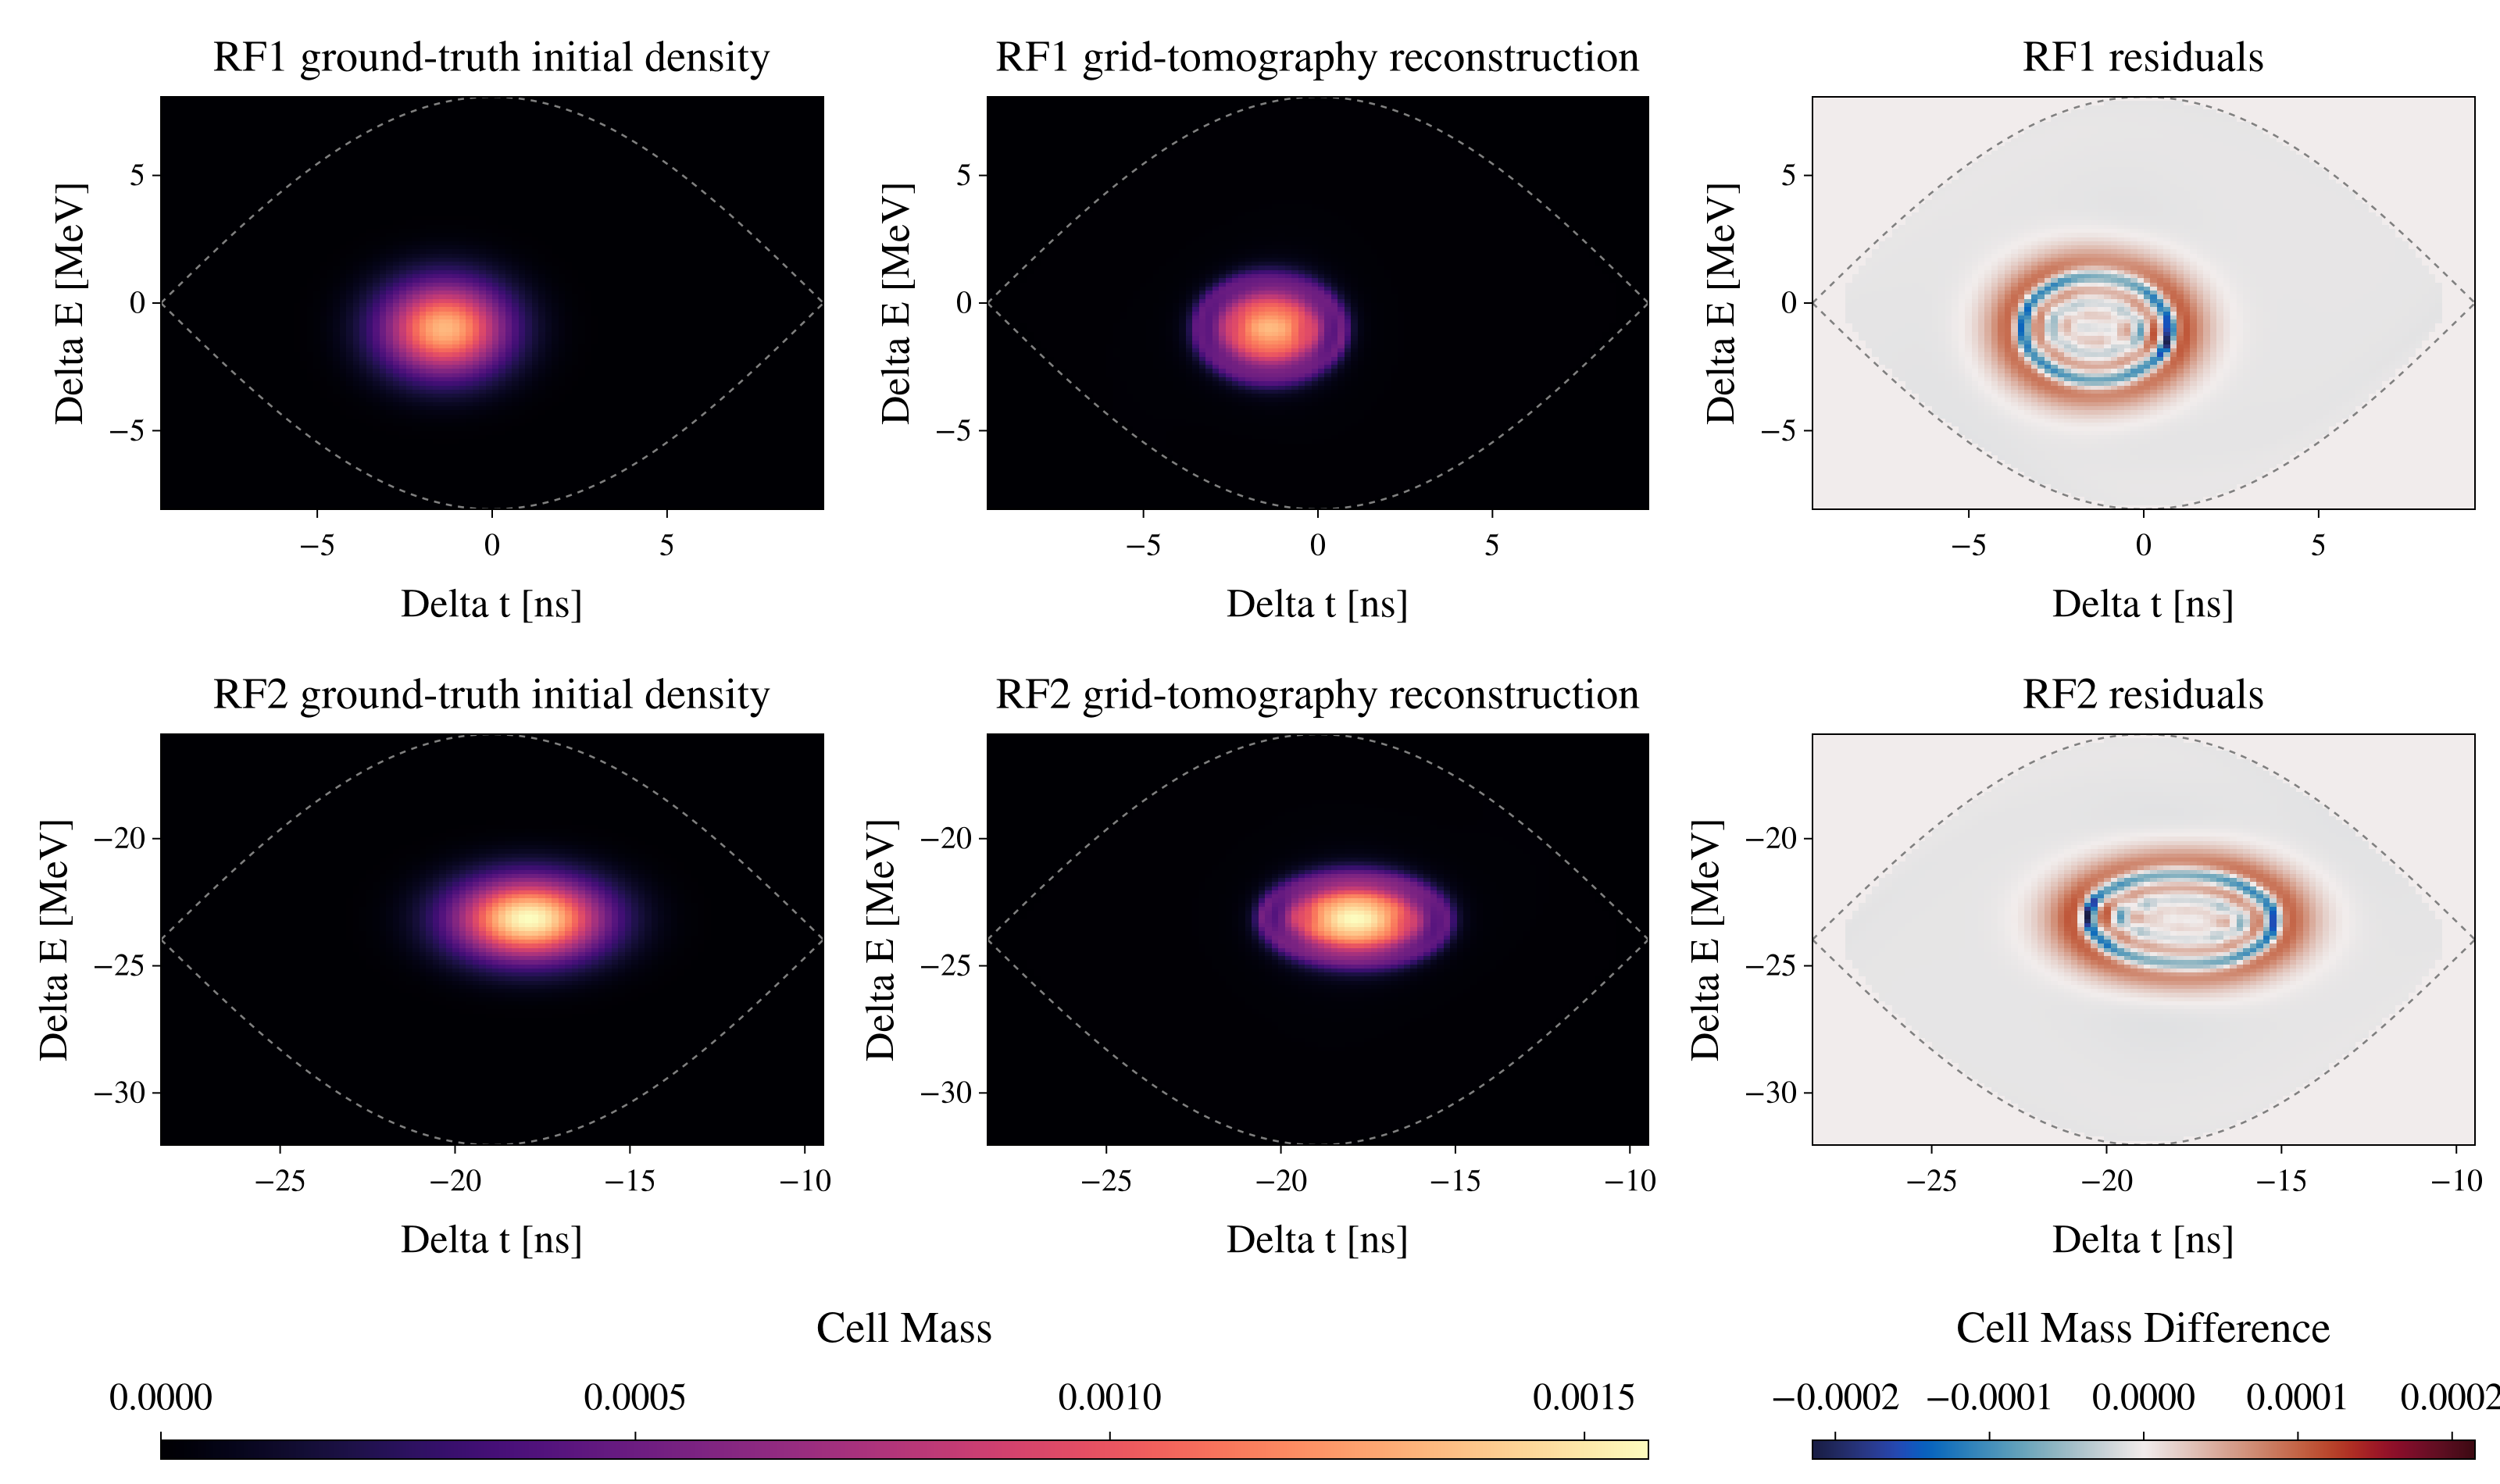

CairoMakie.Screen{IMAGE}


In [11]:
# ------------------------------------------------------------
# Initial-density reconstruction plots in physical coordinates
# One row for RF1 bunch, one row for RF2 bunch
# ------------------------------------------------------------

function heatmap_axes_from_local_grid(
    grid,
    spec::BucketSpec,
    machine::NonInteractingTwoRFMachine;
    turn=first(response.turns),
    N0=response.reference_turn,
)
    if spec.family == :rf1
        theta_axis_absolute =
            grid.theta_axis .+
            2pi * spec.bucket_index

        P_axis_rf1 = grid.P_axis
    elseif spec.family == :rf2
        slip_phase = only(rf2_center_phase([turn], machine; N0=N0))

        theta_axis_absolute =
            grid.theta_axis .+
            2pi * spec.bucket_index .+
            slip_phase

        momentum_scale =
            synchrotron_tune(machine.rf2) /
            synchrotron_tune(machine.rf1)

        P_axis_rf1 =
            momentum_scale .* grid.P_axis .+
            slip_stacking_parameter(machine)
    else
        error("Unknown family $(spec.family)")
    end

    delta_t_axis_ns =
        delta_t_from_theta(theta_axis_absolute, machine.rf1) .* 1e9

    delta_E_axis_MeV =
        delta_energy_from_P(P_axis_rf1, machine.rf1) .* 1e-6

    return delta_t_axis_ns, delta_E_axis_MeV
end

function separatrix_physical_coordinates(
    spec::BucketSpec,
    machine::NonInteractingTwoRFMachine;
    turn=first(response.turns),
    N0=response.reference_turn,
    n_points=700,
)
    theta_local = collect(range(-pi, pi; length=n_points))
    P_upper_local = 2 .* cos.(theta_local ./ 2)
    P_lower_local = -P_upper_local

    if spec.family == :rf1
        theta_absolute =
            theta_local .+
            2pi * spec.bucket_index

        P_upper_rf1 = P_upper_local
        P_lower_rf1 = P_lower_local
    elseif spec.family == :rf2
        slip_phase = only(rf2_center_phase([turn], machine; N0=N0))

        theta_absolute =
            theta_local .+
            2pi * spec.bucket_index .+
            slip_phase

        momentum_scale =
            synchrotron_tune(machine.rf2) /
            synchrotron_tune(machine.rf1)

        P_upper_rf1 =
            slip_stacking_parameter(machine) .+
            momentum_scale .* P_upper_local

        P_lower_rf1 =
            slip_stacking_parameter(machine) .+
            momentum_scale .* P_lower_local
    else
        error("Unknown family $(spec.family)")
    end

    delta_t_ns =
        delta_t_from_theta(theta_absolute, machine.rf1) .* 1e9

    delta_E_upper_MeV =
        delta_energy_from_P(P_upper_rf1, machine.rf1) .* 1e-6

    delta_E_lower_MeV =
        delta_energy_from_P(P_lower_rf1, machine.rf1) .* 1e-6

    return delta_t_ns, delta_E_upper_MeV, delta_E_lower_MeV
end

function orient_for_heatmap(x_axis, y_axis, matrix_P_by_theta)
    heatmap_matrix = permutedims(matrix_P_by_theta)

    if !issorted(x_axis)
        x_order = sortperm(x_axis)
        x_axis = x_axis[x_order]
        heatmap_matrix = heatmap_matrix[x_order, :]
    end

    if !issorted(y_axis)
        y_order = sortperm(y_axis)
        y_axis = y_axis[y_order]
        heatmap_matrix = heatmap_matrix[:, y_order]
    end

    return x_axis, y_axis, heatmap_matrix
end

rf1_spec = bucket_specs[1]
rf2_spec = bucket_specs[2]

rf1_dt_ns, rf1_dE_MeV = heatmap_axes_from_local_grid(
    grid,
    rf1_spec,
    two_rf,
)

rf2_dt_ns, rf2_dE_MeV = heatmap_axes_from_local_grid(
    grid,
    rf2_spec,
    two_rf,
)

rf1_target_dt_ns, rf1_target_dE_MeV, rf1_target_matrix_plot =
    orient_for_heatmap(rf1_dt_ns, rf1_dE_MeV, true_rf1_matrix)

rf1_reco_dt_ns, rf1_reco_dE_MeV, rf1_reco_matrix_plot =
    orient_for_heatmap(rf1_dt_ns, rf1_dE_MeV, reco_rf1_matrix)

rf2_target_dt_ns, rf2_target_dE_MeV, rf2_target_matrix_plot =
    orient_for_heatmap(rf2_dt_ns, rf2_dE_MeV, true_rf2_matrix)

rf2_reco_dt_ns, rf2_reco_dE_MeV, rf2_reco_matrix_plot =
    orient_for_heatmap(rf2_dt_ns, rf2_dE_MeV, reco_rf2_matrix)

rf1_difference_matrix = rf1_target_matrix_plot .- rf1_reco_matrix_plot
rf2_difference_matrix = rf2_target_matrix_plot .- rf2_reco_matrix_plot

rf1_sep_dt_ns, rf1_sep_upper_MeV, rf1_sep_lower_MeV =
    separatrix_physical_coordinates(rf1_spec, two_rf)

rf2_sep_dt_ns, rf2_sep_upper_MeV, rf2_sep_lower_MeV =
    separatrix_physical_coordinates(rf2_spec, two_rf)

common_colorrange = (
    0.0,
    max(
        maximum(rf1_target_matrix_plot),
        maximum(rf1_reco_matrix_plot),
        maximum(rf2_target_matrix_plot),
        maximum(rf2_reco_matrix_plot),
    ),
)

difference_limit = max(
    maximum(abs.(rf1_difference_matrix)),
    maximum(abs.(rf2_difference_matrix)),
    eps(Float64),
)

phase_figure = Figure(size=(1600, 950))

axis_style = (
    titlefont="StixGeneral",
    titlesize=28,
    xlabelfont="StixGeneral",
    ylabelfont="StixGeneral",
    xlabelsize=26,
    ylabelsize=26,
    xticklabelfont="StixGeneral",
    yticklabelfont="StixGeneral",
    xticklabelsize=20,
    yticklabelsize=20,
)

axis_rf1_target = Axis(
    phase_figure[1, 1];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="RF1 ground-truth initial density",
    axis_style...,
)

target_heatmap = heatmap!(
    axis_rf1_target,
    rf1_target_dt_ns,
    rf1_target_dE_MeV,
    rf1_target_matrix_plot;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_rf1_reco = Axis(
    phase_figure[1, 2];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="RF1 grid-tomography reconstruction",
    axis_style...,
)

heatmap!(
    axis_rf1_reco,
    rf1_reco_dt_ns,
    rf1_reco_dE_MeV,
    rf1_reco_matrix_plot;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_rf1_difference = Axis(
    phase_figure[1, 3];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="RF1 residuals",
    axis_style...,
)

difference_heatmap = heatmap!(
    axis_rf1_difference,
    rf1_target_dt_ns,
    rf1_target_dE_MeV,
    rf1_difference_matrix;
    colormap=:balance,
    colorrange=(-difference_limit, difference_limit),
)

axis_rf2_target = Axis(
    phase_figure[2, 1];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="RF2 ground-truth initial density",
    axis_style...,
)

heatmap!(
    axis_rf2_target,
    rf2_target_dt_ns,
    rf2_target_dE_MeV,
    rf2_target_matrix_plot;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_rf2_reco = Axis(
    phase_figure[2, 2];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="RF2 grid-tomography reconstruction",
    axis_style...,
)

heatmap!(
    axis_rf2_reco,
    rf2_reco_dt_ns,
    rf2_reco_dE_MeV,
    rf2_reco_matrix_plot;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_rf2_difference = Axis(
    phase_figure[2, 3];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="RF2 residuals",
    axis_style...,
)

heatmap!(
    axis_rf2_difference,
    rf2_target_dt_ns,
    rf2_target_dE_MeV,
    rf2_difference_matrix;
    colormap=:balance,
    colorrange=(-difference_limit, difference_limit),
)

for axis in (axis_rf1_target, axis_rf1_reco, axis_rf1_difference)
    lines!(
        axis,
        rf1_sep_dt_ns,
        rf1_sep_upper_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )

    lines!(
        axis,
        rf1_sep_dt_ns,
        rf1_sep_lower_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )
end

for axis in (axis_rf2_target, axis_rf2_reco, axis_rf2_difference)
    lines!(
        axis,
        rf2_sep_dt_ns,
        rf2_sep_upper_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )

    lines!(
        axis,
        rf2_sep_dt_ns,
        rf2_sep_lower_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )
end

Colorbar(
    phase_figure[3, 1:2],
    target_heatmap;
    vertical=false,
    label="Cell Mass",
    labelsize=28,
    ticklabelsize=24,
    ticklabelfont="StixGeneral",
    labelfont="StixGeneral",
)

Colorbar(
    phase_figure[3, 3],
    difference_heatmap;
    vertical=false,
    label="Cell Mass Difference",
    labelsize=28,
    ticklabelsize=24,
    ticklabelfont="StixGeneral",
    labelfont="StixGeneral",
)

display(phase_figure)